In [1]:
!nvidia-smi

Thu Oct  1 15:27:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import sys
import torch

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))
print("VRAM GB:", torch.cuda.get_device_properties(0).total_memory / 1024**3)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch: 2.11.0+cu128
CUDA: 12.8
GPU: Tesla T4
VRAM GB: 14.56317138671875


# Environment settings

In [ ]:
import sys
import torch
import numpy as np

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("NumPy:", np.__version__)

try:
    import torchaudio
    print("torchaudio:", torchaudio.__version__)
except Exception as e:
    print("torchaudio ERROR:", e)

try:
    import librosa
    print("librosa:", librosa.__version__)
except Exception as e:
    print("librosa ERROR:", e)

try:
    import sklearn
    print("scikit-learn:", sklearn.__version__)
except Exception as e:
    print("scikit-learn ERROR:", e)

try:
    import pytorch_lightning as pl
    print("PyTorch Lightning:", pl.__version__)
except Exception as e:
    print("PyTorch Lightning ERROR:", e)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch: 2.11.0+cu128
NumPy: 2.1.3
torchaudio: 2.11.0+cu128
librosa: 0.11.0
scikit-learn: 1.6.1
PyTorch Lightning ERROR: No module named 'pytorch_lightning'


In [2]:
!pip install pytorch-lightning==2.6.6
!pip install torchinfo==1.8.0 separableconv-torch==0.1.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.0/853.0 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 64.3 MB/s eta 0:00:00


In [3]:
import sys
import torch
import torchaudio
import pytorch_lightning as pl

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("torchaudio:", torchaudio.__version__)
print("Lightning:", pl.__version__)
print("CUDA disponibile:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch: 2.11.0+cu128
torchaudio: 2.11.0+cu128
Lightning: 2.6.6
CUDA disponibile: True
GPU: Tesla T4


In [ ]:
modules = [
    "numpy",
    "torch",
    "torchaudio",
    "librosa",
    "sklearn",
    "pytorch_lightning",
    "torchmetrics",
    "torchinfo",
    "wandb",
    "separableconv",
]

for m in modules:
    try:
        mod = __import__(m)
        version = getattr(mod, "__version__", "versione non disponibile")
        print(f"{m:20s} OK   {version}")
    except Exception as e:
        print(f"{m:20s} MISSING/ERROR   {e}")

numpy                OK   2.1.3
torch                OK   2.11.0+cu128
torchaudio           OK   2.11.0+cu128
librosa              OK   0.11.0
sklearn              OK   1.6.1
pytorch_lightning    OK   2.6.6
torchmetrics         OK   1.9.0
torchinfo            OK   1.8.0
wandb                OK   0.28.1
separableconv        OK   0.1.0+torch2.11.0+cu128


# Cloning Repository

In [ ]:
!rm -rf /content/unsupervised-audio-anomaly-detection

In [ ]:
!git clone \
  --branch multichannel-mimii \
  --single-branch \
  https://github.com/jacopociotti/unsupervised-audio-anomaly-detection.git

Cloning into 'unsupervised-audio-anomaly-detection'...
remote: Enumerating objects: 90, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (63/63), done.
remote: Total 90 (delta 39), reused 66 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (90/90), 16.47 MiB | 16.76 MiB/s, done.
Resolving deltas: 100% (39/39), done.


In [ ]:
!git branch -vv
!git remote -v
!ls -la

* multichannel-mimii 2e8e202 [origin/multichannel-mimii] Fix per-machine evaluation and set 10 training epochs
origin	https://github.com/jacopociotti/unsupervised-audio-anomaly-detection.git (fetch)
origin	https://github.com/jacopociotti/unsupervised-audio-anomaly-detection.git (push)
total 15996
drwxr-xr-x 6 root root     4096 Sep 29 12:38 .
drwxr-xr-x 1 root root     4096 Sep 29 12:38 ..
drwxr-xr-x 2 root root     4096 Sep 29 12:38 best_models
-rw-r--r-- 1 root root     4529 Sep 29 12:38 conda_requirements.txt
-rw-r--r-- 1 root root    10925 Sep 29 12:38 data.py
drwxr-xr-x 8 root root     4096 Sep 29 12:38 .git
-rw-r--r-- 1 root root     3194 Sep 29 12:38 .gitignore
drwxr-xr-x 2 root root     4096 Sep 29 12:38 images
-rw-r--r-- 1 root root     1069 Sep 29 12:38 LICENSE
-rw-r--r-- 1 root root     3526 Sep 29 12:38 mobilenet.py
-rw-r--r-- 1 root root    12834 Sep 29 12:38 model.py
-rw-r--r-- 1 root root 11078312 Sep 29 12:38 MWM_93.44_s40_m0.7.ckpt
drwxr-xr-x 2 root root     4096 Sep 2

# Importing Data

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!cp -r "/content/drive/MyDrive/DACLS/unsupervised-audio-anomaly-detection" "/content/"

In [6]:
%cd /content/unsupervised-audio-anomaly-detection

/content/unsupervised-audio-anomaly-detection


In [7]:
from data import MIMIIDataModule
from model import Wavegram_AttentionMap

print("Import progetto: OK")

Import progetto: OK


In [8]:
!unzip -q "/content/drive/MyDrive/DACLS/dataset_0dB.zip" -d /content/

error:  zipfile read error


In [9]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/DACLS/dataset_0dB.zip"
extract_path = "/content/"

try:
    print("Apertura del file ZIP in corso...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        print("Inizio estrazione intelligente (riprendendo dal punto di interruzione)...")

        skipped_count = 0
        extracted_count = 0

        for file_info in zip_ref.infolist():
            # Determina dove dovrebbe essere estratto il file
            target_file_path = os.path.join(extract_path, file_info.filename)

            # Se è una directory, la creiamo se non esiste e continuiamo
            if file_info.is_dir():
                os.makedirs(target_file_path, exist_ok=True)
                continue

            # Controlla se il file esiste già ed ha la stessa dimensione dello ZIP
            if os.path.exists(target_file_path) and os.path.getsize(target_file_path) == file_info.file_size:
                skipped_count += 1
                continue

            # Estrai solo se manca o è incompleto
            try:
                zip_ref.extract(file_info, extract_path)
                extracted_count += 1
                if extracted_count % 500 == 0:
                    print(f"Estratti {extracted_count} nuovi file... (Saltati già presenti: {skipped_count})")
            except Exception as e:
                print(f"Errore durante l'estrazione di {file_info.filename}: {e}")

        print(f"\nProcesso completato!")
        print(f"File già presenti e saltati: {skipped_count}")
        print(f"Nuovi file estratti con successo: {extracted_count}")
except Exception as e:
    print("Impossibile aprire o gestire il file ZIP:", e)

Apertura del file ZIP in corso...
Inizio estrazione intelligente (riprendendo dal punto di interruzione)...
Estratti 500 nuovi file... (Saltati già presenti: 15831)
Estratti 1000 nuovi file... (Saltati già presenti: 15831)
Estratti 1500 nuovi file... (Saltati già presenti: 15831)
Estratti 2000 nuovi file... (Saltati già presenti: 15831)

Processo completato!
File già presenti e saltati: 15831
Nuovi file estratti con successo: 2188


In [10]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/DACLS/dataset_0dB.zip"
extract_path = "/content/"

try:
    print("Avvio del controllo di coerenza...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        missing_files = []
        size_mismatches = []
        total_files = 0

        for file_info in zip_ref.infolist():
            # Ignoriamo le directory nel conteggio dei singoli file
            if file_info.is_dir():
                continue

            total_files += 1
            target_file_path = os.path.join(extract_path, file_info.filename)

            # Verifica esistenza
            if not os.path.exists(target_file_path):
                missing_files.append(file_info.filename)
            else:
                # Verifica dimensione
                extracted_size = os.path.getsize(target_file_path)
                if extracted_size != file_info.file_size:
                    size_mismatches.append((
                        file_info.filename,
                        file_info.file_size,
                        extracted_size
                    ))

        print(f"\n--- RISULTATO DEL CONFRONTO ---")
        print(f"File totali analizzati nello ZIP: {total_files}")

        if not missing_files and not size_mismatches:
            print("\nSUCCESS: Tutti i file sono stati estratti correttamente! Le dimensioni corrispondono al 100%.")
        else:
            if missing_files:
                print(f"\nATTENZIONE: Mancano all'appello {len(missing_files)} file.")
                print("Primi 5 file mancanti:", missing_files[:5])
            if size_mismatches:
                print(f"\nATTENZIONE: {len(size_mismatches)} file hanno una dimensione diversa.")
                print("Primi 5 file corrotti/incompleti:", size_mismatches[:5])

except Exception as e:
    print("Errore durante l'apertura dello ZIP:", e)

Avvio del controllo di coerenza...

--- RISULTATO DEL CONFRONTO ---
File totali analizzati nello ZIP: 18019

SUCCESS: Tutti i file sono stati estratti correttamente! Le dimensioni corrispondono al 100%.


# Model

In [11]:
%cd /content/unsupervised-audio-anomaly-detection

from data import MIMIIDataModule

dm = MIMIIDataModule(
    path_data="/content/dataset_0dB",
    sample_rate=16000,
    duration=10,
    batch_size=4,
    num_channels=8,
    spatial_augmentation=False
)

print("Train:", len(dm.train_list))
print("Validation:", len(dm.val_list))
print("Test:", len(dm.test_list))
print("Totale:", len(dm.train_list) + len(dm.val_list) + len(dm.test_list))
train_loader = dm.train_dataloader()

audio, metadata, label, numerical_label = next(iter(train_loader))

print("Audio shape:", audio.shape)
print("Metadata shape:", metadata.shape)
print("Label shape:", label.shape)
print("Numerical label shape:", numerical_label.shape)
print("Audio dtype:", audio.dtype)

/content/unsupervised-audio-anomaly-detection
Train: 10296
Validation: 1465
Test: 6258
Totale: 18019
Audio shape: torch.Size([4, 8, 160000])
Metadata shape: torch.Size([4])
Label shape: torch.Size([4])
Numerical label shape: torch.Size([4])
Audio dtype: torch.float32


In [ ]:
!rm -f best_models/mimii-8ch-aug0-*.ckpt
!rm -f best_models/mimii-1ch-aug0-*.ckpt
!rm -f best_models/mimii-4ch-aug0-*.ckpt
!rm -f best_models/last*.ckpt

In [ ]:
!rm -rf lightning_logs
!mkdir -p best_models

# 1 ch.

In [ ]:
import torch
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

In [ ]:
%run training_mimii.py \
    --path_data "/content/dataset_0dB" \
    --num_channels 1 \
    --batch_size 32 \
    --epochs 100 \
    --lr 0.0001

INFO:lightning_fabric.utilities.seed:Seed set to 42


----- MIMII experiment -----
Seed: 42
Dataset: /content/dataset_0dB
Channels: 1
Spatial augmentation: False
Classes: 16
Batch size: 32
Epochs: 100
Learning rate: 0.0001


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.13/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/unsupervised-audio-anomaly-detection/best_models exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name              ┃ Type                     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model             │ Wavegram_AttentionModule │  877 K │ train │     0 │
│ 1 │ accuracy_training │ MulticlassAccuracy       │      0 │ train │     0 │
│ 2 │ accuracy_val      │ MulticlassAccuracy       │      0 │ train │     0 │
│ 3 │ accuracy_test     │ MulticlassAccuracy       │      0 │ train │     0 │
│ 4 │ criterion         │ CrossEntropyLoss         │      0 │ train │     0 │
└───┴───────────────────┴──────────────────────────┴────────┴───────┴───────┘

Trainable params: 877 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 877 K                                                                                                
Total estimated model params size (MB): 3.512                                                                      
Modules in train mode: 124                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/unsupervised-audio-anomaly-detection/best_models/mimii-1ch-aug0-21-0.0235.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /content/unsupervised-audio-anomaly-detection/best_models/mimii-1ch-aug0-21-0.0235.ckpt


Output()

Best checkpoint: /content/unsupervised-audio-anomaly-detection/best_models/mimii-1ch-aug0-21-0.0235.ckpt


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │     0.672259509563446     │
│      test/loss_class      │     8.626623153686523     │
└───────────────────────────┴───────────────────────────┘


----- TEST INFO -----
Samples: 6258
Normal: 2958
Abnormal: 3300
Labels presenti: [0 1]

----- TEST RESULTS -----
Samples: 6258
Normal: 2958
Abnormal: 3300
AUC:  0.8483
pAUC: 0.8246

----- RESULTS BY MACHINE -----
Fan: AUC=0.7647, pAUC=0.7423, N=2293
Pump: AUC=0.9252, pAUC=0.8512, N=1209
Slider: AUC=0.9904, pAUC=0.9513, N=1536
Valve: AUC=0.9785, pAUC=0.9251, N=1220


In [ ]:
import torch

peak_allocated = torch.cuda.max_memory_allocated() / 1024**3
peak_reserved = torch.cuda.max_memory_reserved() / 1024**3

print(f"Peak allocated: {peak_allocated:.2f} GB")
print(f"Peak reserved:  {peak_reserved:.2f} GB")
print(f"GPU totale:     {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

Peak allocated: 5.20 GB
Peak reserved:  6.08 GB
GPU totale:     14.56 GB


# 4 ch. no spatial

In [ ]:
import torch
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

In [ ]:
%run training_mimii.py \
    --path_data "/content/dataset_0dB" \
    --output_dir "/content/drive/MyDrive/DACLS/experiments/4ch_no_spatial" \
    --num_channels 4 \
    --batch_size 32 \
    --epochs 100 \
    --lr 0.0001

Testing ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196/196 0:02:06 • 0:00:00 1.45it/s

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.6701821684837341     │
│      test/loss_class      │     8.955113410949707     │
└───────────────────────────┴───────────────────────────┘


----- TEST INFO -----
Samples: 6258
Normal: 2958
Abnormal: 3300
Labels presenti: [0 1]

----- TEST RESULTS -----
Samples: 6258
Normal: 2958
Abnormal: 3300
AUC:  0.9203
pAUC: 0.8625

----- RESULTS BY MACHINE -----
Fan: AUC=0.8874, pAUC=0.8199, N=2293
Pump: AUC=0.8927, pAUC=0.8506, N=1209
Slider: AUC=0.9992, pAUC=0.9960, N=1536
Valve: AUC=0.9892, pAUC=0.9646, N=1220


# 4 ch. si spatial

In [ ]:
import torch
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

In [ ]:
%run training_mimii.py \
    --path_data "/content/dataset_0dB" \
    --output_dir "/content/drive/MyDrive/DACLS/experiments/4ch_si_spatial" \
    --num_channels 4 \
    --batch_size 32 \
    --num_classes 16 \
    --epochs 100 \
    --lr 0.0001 \
    --spatial_augmentation

INFO:lightning_fabric.utilities.seed:Seed set to 42


----- MIMII experiment -----
Seed: 42
Dataset: /content/dataset_0dB
Channels: 4
Spatial augmentation: True
Classes: 16
Batch size: 32
Epochs: 100
Learning rate: 0.0001


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name              ┃ Type                     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model             │ Wavegram_AttentionModule │  881 K │ train │     0 │
│ 1 │ accuracy_training │ MulticlassAccuracy       │      0 │ train │     0 │
│ 2 │ accuracy_val      │ MulticlassAccuracy       │      0 │ train │     0 │
│ 3 │ accuracy_test     │ MulticlassAccuracy       │      0 │ train │     0 │
│ 4 │ criterion         │ CrossEntropyLoss         │      0 │ train │     0 │
└───┴───────────────────┴──────────────────────────┴────────┴───────┴───────┘

Trainable params: 881 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 881 K                                                                                                
Total estimated model params size (MB): 3.528                                                                      
Modules in train mode: 124                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/drive/.shortcut-targets-by-id/1XvRJXITHcM2FTazt665xrNWAjhGezNc2/DACLS/experiments/4ch_si_spatial/best_models/mimii-4ch-aug1-36-0.0022.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /content/drive/.shortcut-targets-by-id/1XvRJXITHcM2FTazt665xrNWAjhGezNc2/DACLS/experiments/4ch_si_spatial/best_models/mimii-4ch-aug1-36-0.0022.ckpt


Best checkpoint: /content/drive/.shortcut-targets-by-id/1XvRJXITHcM2FTazt665xrNWAjhGezNc2/DACLS/experiments/4ch_si_spatial/best_models/mimii-4ch-aug1-36-0.0022.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.6669862866401672     │
│      test/loss_class      │    10.190869331359863     │
└───────────────────────────┴───────────────────────────┘


----- TEST INFO -----
Samples: 6258
Normal: 2958
Abnormal: 3300
Labels presenti: [0 1]

----- TEST RESULTS -----
Samples: 6258
Normal: 2958
Abnormal: 3300
AUC:  0.9074
pAUC: 0.8550

----- RESULTS BY MACHINE -----
Fan: AUC=0.8823, pAUC=0.7747, N=2293
Pump: AUC=0.9191, pAUC=0.8900, N=1209
Slider: AUC=0.9990, pAUC=0.9947, N=1536
Valve: AUC=0.9927, pAUC=0.9765, N=1220


# 8 ch. no spatial

In [ ]:
import torch
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

In [ ]:
%run training_mimii.py \
    --path_data "/content/dataset_0dB" \
    --output_dir "/content/drive/MyDrive/DACLS/experiments/8ch_no_spatial" \
    --num_channels 8 \
    --batch_size 32 \
    --num_classes 16 \
    --epochs 100 \
    --lr 0.0001

INFO:lightning_fabric.utilities.seed:Seed set to 42


----- MIMII experiment -----
Seed: 42
Dataset: /content/dataset_0dB
Channels: 8
Spatial augmentation: False
Classes: 16
Batch size: 32
Epochs: 100
Learning rate: 0.0001


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name              ┃ Type                     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model             │ Wavegram_AttentionModule │  887 K │ train │     0 │
│ 1 │ accuracy_training │ MulticlassAccuracy       │      0 │ train │     0 │
│ 2 │ accuracy_val      │ MulticlassAccuracy       │      0 │ train │     0 │
│ 3 │ accuracy_test     │ MulticlassAccuracy       │      0 │ train │     0 │
│ 4 │ criterion         │ CrossEntropyLoss         │      0 │ train │     0 │
└───┴───────────────────┴──────────────────────────┴────────┴───────┴───────┘

Trainable params: 887 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 887 K                                                                                                
Total estimated model params size (MB): 3.549                                                                      
Modules in train mode: 124                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Best checkpoint: /content/drive/.shortcut-targets-by-id/1XvRJXITHcM2FTazt665xrNWAjhGezNc2/DACLS/experiments/8ch_no_spatial/best_models/mimii-8ch-aug0-36-0.0047.ckpt


INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /content/drive/.shortcut-targets-by-id/1XvRJXITHcM2FTazt665xrNWAjhGezNc2/DACLS/experiments/8ch_no_spatial/best_models/mimii-8ch-aug0-36-0.0047.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.6845637559890747     │
│      test/loss_class      │    10.818975448608398     │
└───────────────────────────┴───────────────────────────┘


----- TEST INFO -----
Samples: 6258
Normal: 2958
Abnormal: 3300
Labels presenti: [0 1]

----- TEST RESULTS -----
Samples: 6258
Normal: 2958
Abnormal: 3300
AUC:  0.9027
pAUC: 0.8648

----- RESULTS BY MACHINE -----
Fan: AUC=0.8614, pAUC=0.8068, N=2293
Pump: AUC=0.9143, pAUC=0.8788, N=1209
Slider: AUC=0.9978, pAUC=0.9882, N=1536
Valve: AUC=0.9914, pAUC=0.9739, N=1220


# 8 ch. si spatial

In [13]:
import torch
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

In [ ]:
%run training_mimii.py \
    --path_data "/content/dataset_0dB" \
    --output_dir "/content/drive/MyDrive/DACLS/experiments/8ch_si_spatial" \
    --num_channels 8 \
    --batch_size 32 \
    --num_classes 16 \
    --epochs 100 \
    --lr 0.0001 \
    --spatial_augmentation

INFO:lightning_fabric.utilities.seed:Seed set to 42


----- MIMII experiment -----
Seed: 42
Dataset: /content/dataset_0dB
Channels: 8
Spatial augmentation: True
Classes: 16
Batch size: 32
Epochs: 100
Learning rate: 0.0001


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name              ┃ Type                     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model             │ Wavegram_AttentionModule │  887 K │ train │     0 │
│ 1 │ accuracy_training │ MulticlassAccuracy       │      0 │ train │     0 │
│ 2 │ accuracy_val      │ MulticlassAccuracy       │      0 │ train │     0 │
│ 3 │ accuracy_test     │ MulticlassAccuracy       │      0 │ train │     0 │
│ 4 │ criterion         │ CrossEntropyLoss         │      0 │ train │     0 │
└───┴───────────────────┴──────────────────────────┴────────┴───────┴───────┘

Trainable params: 887 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 887 K                                                                                                
Total estimated model params size (MB): 3.549                                                                      
Modules in train mode: 124                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/drive/.shortcut-targets-by-id/1XvRJXITHcM2FTazt665xrNWAjhGezNc2/DACLS/experiments/8ch_si_spatial/best_models/mimii-8ch-aug1-36-0.0008.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /content/drive/.shortcut-targets-by-id/1XvRJXITHcM2FTazt665xrNWAjhGezNc2/DACLS/experiments/8ch_si_spatial/best_models/mimii-8ch-aug1-36-0.0008.ckpt


Best checkpoint: /content/drive/.shortcut-targets-by-id/1XvRJXITHcM2FTazt665xrNWAjhGezNc2/DACLS/experiments/8ch_si_spatial/best_models/mimii-8ch-aug1-36-0.0008.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │     0.674336850643158     │
│      test/loss_class      │     10.73891544342041     │
└───────────────────────────┴───────────────────────────┘


----- TEST INFO -----
Samples: 6258
Normal: 2958
Abnormal: 3300
Labels presenti: [0 1]

----- TEST RESULTS -----
Samples: 6258
Normal: 2958
Abnormal: 3300
AUC:  0.9112
pAUC: 0.8661

----- RESULTS BY MACHINE -----
Fan: AUC=0.8681, pAUC=0.8178, N=2293
Pump: AUC=0.9365, pAUC=0.9043, N=1209
Slider: AUC=0.9958, pAUC=0.9785, N=1536
Valve: AUC=0.9963, pAUC=0.9841, N=1220


# ROC curve


1ch no spatial
Checkpoint:
/content/drive/MyDrive/DACLS/experiments/1ch_no_spatial/best_models/mimii-1ch-aug0-21-0.0235.ckpt


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │     0.672259509563446     │
│      test/loss_class      │     8.626623153686523     │
└───────────────────────────┴───────────────────────────┘

...

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │     0.674336850643158     │
│      test/loss_class      │     10.73891544342041     │
└───────────────────────────┴───────────────────────────┘

Samples: 6258
AUC: 0.9112


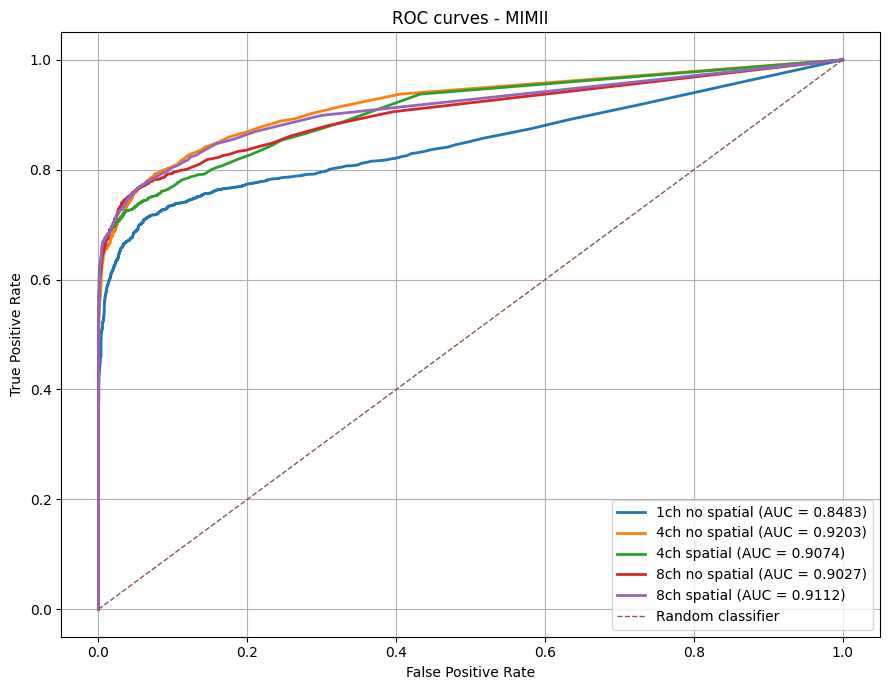


ROC salvate in:
/content/drive/MyDrive/DACLS/experiments/roc_results_global


In [14]:
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, roc_auc_score
from pytorch_lightning import Trainer

from data import MIMIIDataModule
from model import Wavegram_AttentionMap


# ============================================================
# CONFIGURAZIONE
# ============================================================

DATASET_PATH = "/content/dataset_0dB"

# MODIFICA questi path se i checkpoint sono in cartelle diverse
CHECKPOINTS = {
    "1ch no spatial":
        "/content/drive/MyDrive/DACLS/experiments/1ch_no_spatial/best_models",

    "4ch no spatial":
        "/content/drive/MyDrive/DACLS/experiments/4ch_no_spatial/best_models",

    "4ch spatial":
        "/content/drive/MyDrive/DACLS/experiments/4ch_si_spatial/best_models",

    "8ch no spatial":
        "/content/drive/MyDrive/DACLS/experiments/8ch_no_spatial/best_models",

    "8ch spatial":
        "/content/drive/MyDrive/DACLS/experiments/8ch_si_spatial/best_models",
}

NUM_CHANNELS = {
    "1ch no spatial": 1,
    "4ch no spatial": 4,
    "4ch spatial": 4,
    "8ch no spatial": 8,
    "8ch spatial": 8,
}

BATCH_SIZE = 32


# ============================================================
# TROVA IL CHECKPOINT .ckpt
# ============================================================

def find_checkpoint(folder):
    folder = Path(folder)

    checkpoints = [
        p for p in folder.glob("*.ckpt")
        if "last" not in p.name.lower()
    ]

    if len(checkpoints) == 0:
        raise FileNotFoundError(
            f"Nessun checkpoint trovato in:\n{folder}"
        )

    if len(checkpoints) > 1:
        print(f"ATTENZIONE: più checkpoint trovati in {folder}")
        for ckpt in checkpoints:
            print("  ", ckpt)

    return sorted(checkpoints)[0]


# ============================================================
# ESEGUE SOLO IL TEST E RECUPERA errors + labels
# ============================================================

def get_anomaly_scores(checkpoint_path, num_channels):

    datamodule = MIMIIDataModule(
        path_data=DATASET_PATH,
        sample_rate=16000,
        duration=10,
        batch_size=BATCH_SIZE,
        num_channels=num_channels,
        spatial_augmentation=False
    )

    # Carichiamo direttamente il modello migliore
    model = Wavegram_AttentionMap.load_from_checkpoint(
        checkpoint_path,
        h=128,
        lr=0.0001,
        num_classes=16,
        num_channels=num_channels
    )

    # Pulizia come nel evaluate()
    model.errors_list = []
    model.clean_errors = []
    model.anomaly_errors = []
    model.labels = []
    model.classes = []

    trainer = Trainer(
        accelerator="gpu",
        devices=1,
        logger=False,
        enable_checkpointing=False,
        enable_progress_bar=True
    )

    # Il modello è già caricato dal checkpoint
    trainer.test(
        model,
        datamodule=datamodule
    )

    # IDENTICO al evaluate()
    errors = torch.cat(
        [x.detach().cpu() for x in model.errors_list]
    ).numpy()

    labels = torch.cat(
        [x.detach().cpu() for x in model.labels]
    ).numpy()

    return labels, errors


# ============================================================
# CALCOLO ROC
# ============================================================

roc_results = {}

for name, folder in CHECKPOINTS.items():

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    ckpt = find_checkpoint(folder)

    print("Checkpoint:")
    print(ckpt)

    labels, errors = get_anomaly_scores(
        str(ckpt),
        NUM_CHANNELS[name]
    )

    fpr, tpr, thresholds = roc_curve(labels, errors)

    auc_value = roc_auc_score(labels, errors)

    roc_results[name] = {
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
        "auc": auc_value,
        "labels": labels,
        "errors": errors
    }

    print(f"Samples: {len(labels)}")
    print(f"AUC: {auc_value:.4f}")


# ============================================================
# GRAFICO DELLE 5 CURVE
# ============================================================

plt.figure(figsize=(9, 7))

for name, result in roc_results.items():

    plt.plot(
        result["fpr"],
        result["tpr"],
        linewidth=2,
        label=f"{name} (AUC = {result['auc']:.4f})"
    )

# classificatore casuale
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves - MIMII")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()

plt.show()


# ============================================================
# SALVATAGGIO DATI ROC SU DRIVE
# ============================================================

SAVE_DIR = Path(
    "/content/drive/MyDrive/DACLS/experiments/roc_results_global"
)

SAVE_DIR.mkdir(parents=True, exist_ok=True)

for name, result in roc_results.items():

    filename = name.replace(" ", "_")

    np.savez(
        SAVE_DIR / f"{filename}.npz",
        labels=result["labels"],
        errors=result["errors"],
        fpr=result["fpr"],
        tpr=result["tpr"],
        thresholds=result["thresholds"],
        auc=result["auc"]
    )

print("\nROC salvate in:")
print(SAVE_DIR)